# 0.3 - Exploratory Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

support_file = Path("SupportData.xlsx")
gl_account_file = Path("GLAccountData.xlsx")
gl_entry_file = Path("GLEntryData.xlsx")

clean_data_dir = Path("outputs") / "cleaned_data"
support_cleaned_file = clean_data_dir / "support_cleaned.csv"
gl_accounts_cleaned_file = clean_data_dir / "gl_accounts_cleaned.csv"
gl_entries_cleaned_file = clean_data_dir / "gl_entries_cleaned.csv"

def read_cleaned_dataset(path):
    if not path.exists():
        raise FileNotFoundError(f"Cleaned dataset not found: {path}. Run 0.2 - Data Cleaning first.")
    df = pd.read_csv(path, low_memory=False)
    for col in df.columns:
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

random_state = 42

def clean_columns(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip().str.replace(".", "_", regex=False).str.replace(" ", "_", regex=False)
    return df

def normalise_key(series):
    return series.astype("string").str.strip().str.upper().str.replace(r"\.0$", "", regex=True)

def normalise_gl_description(series):
    return (series.astype("string").str.upper()
        .str.replace(r"\bCLAIMBACKS?\b", "", regex=True)
        .str.replace(r"\b[A-Z]\d+[A-Z]*\b", "", regex=True)
        .str.replace(r"\bLIMITED\b|\bLTD\b", "", regex=True)
        .str.replace(r"\s+", " ", regex=True).str.strip())

def build_model_base_from_support():
    df = clean_columns(read_cleaned_dataset(support_cleaned_file))
    df["claim_line_id"] = np.arange(1, len(df) + 1)
    df["claim_date"] = pd.to_datetime(df.get("Date"), errors="coerce", dayfirst=True)
    df["customer_date"] = df["claim_date"]
    df["customer_year"] = df["claim_date"].dt.year
    df["customer_month"] = df["claim_date"].dt.month
    qty = pd.to_numeric(df.get("SalesDeliveryNoteLine_Quantity"), errors="coerce").fillna(pd.to_numeric(df.get("SalesInvoiceLine_Quantity"), errors="coerce")).fillna(0)
    unit = pd.to_numeric(df.get("UnitClaimAmount"), errors="coerce").fillna(0)
    total = pd.to_numeric(df.get("TotalClaimAmount"), errors="coerce")
    df["credit_due_value"] = total.fillna(unit * qty)
    credit_note = df.get("SalesCreditNote_Number", pd.Series("", index=df.index)).astype("string").str.strip().ne("").fillna(False)
    df["credit_received_value"] = np.where(credit_note.to_numpy(dtype=bool), df["credit_due_value"].clip(lower=0), 0)
    df["outstanding_credit_value"] = df["credit_due_value"] - df["credit_received_value"]
    df["recovered_credit_rate"] = df["credit_received_value"].div(df["credit_due_value"].replace(0, np.nan)).fillna(0)
    df["supplier_reference_value"] = df["credit_due_value"]
    df["supplier_reference_match_status"] = "Derived from SupportData.xlsx"
    has_received_credit = df["credit_received_value"].gt(0).fillna(False)
    has_outstanding_credit = df["outstanding_credit_value"].gt(0).fillna(False)
    df["credit_recovery_status"] = np.select(
        [has_received_credit.to_numpy(dtype=bool), has_outstanding_credit.to_numpy(dtype=bool)],
        ["Credit note present", "Outstanding"],
        default="No claim value",
    )
    df["days_outstanding"] = (pd.Timestamp.today().normalize() - df["claim_date"]).dt.days
    df["ageing_band"] = pd.cut(df["days_outstanding"], [-1,30,60,90,180,365,np.inf], labels=["0-30","31-60","61-90","91-180","181-365","365+"])
    df["requires_review"] = has_outstanding_credit
    df["review_reason"] = np.where(has_outstanding_credit.to_numpy(dtype=bool), "Outstanding credit value", "")
    return df

def load_gl_context():
    accounts = clean_columns(read_cleaned_dataset(gl_accounts_cleaned_file))
    entries = clean_columns(read_cleaned_dataset(gl_entries_cleaned_file))
    if not accounts.empty:
        accounts["gl_account_code"] = normalise_key(accounts.get("Code", pd.Series(pd.NA,index=accounts.index)))
        accounts["gl_account_description"] = accounts.get("Description", pd.Series(pd.NA,index=accounts.index))
        accounts["gl_supplier_key"] = normalise_gl_description(accounts["gl_account_description"])
        accounts["gl_current_balance"] = pd.to_numeric(accounts.get("CurrentBalance", pd.NA), errors="coerce")
        accounts["gl_current_balance_abs"] = accounts["gl_current_balance"].abs()
    if not entries.empty:
        entries["gl_account_code"] = normalise_key(entries.get("GL_Account_Code", pd.Series(pd.NA,index=entries.index)))
        entries["gl_account_description"] = entries.get("Description", pd.Series(pd.NA,index=entries.index))
        entries["gl_supplier_key"] = normalise_gl_description(entries["gl_account_description"])
        entries["gl_credit_amount"] = pd.to_numeric(entries.get("Credit_Amount", pd.NA), errors="coerce").fillna(0)
        entries["gl_entry_line_date"] = pd.to_datetime(entries.get("Entry_Line_Date", pd.NA), errors="coerce", dayfirst=True)
    if not entries.empty:
        entries["gl_entry_period_month"] = entries["gl_entry_line_date"].dt.to_period("M").astype("string")
        summary = entries.groupby(["gl_account_code","gl_account_description","gl_supplier_key"], dropna=False).agg(
            gl_entry_rows=("gl_account_code","size"),
            gl_total_credit_amount=("gl_credit_amount","sum"),
            gl_first_entry_date=("gl_entry_line_date","min"),
            gl_last_entry_date=("gl_entry_line_date","max"),
        ).reset_index()
        if not accounts.empty:
            account_cols = [col for col in ["gl_account_code", "gl_current_balance", "gl_current_balance_abs"] if col in accounts.columns]
            summary = summary.merge(accounts[account_cols].drop_duplicates("gl_account_code"), on="gl_account_code", how="left")
    else:
        summary = pd.DataFrame()
    return accounts, entries, summary

df = build_model_base_from_support()
gl_accounts_clean, gl_entries_clean, gl_account_summary_clean = load_gl_context()

print("Loaded cleaned datasets from outputs/cleaned_data.")
print("Model base shape:", df.shape)
print("GL summary shape:", gl_account_summary_clean.shape)

gl_accounts = gl_accounts_clean
gl_entries = gl_entries_clean
gl_account_summary = gl_account_summary_clean
supplier_gl_payment_model_base = pd.DataFrame()

display(df.head())
display(gl_account_summary_clean.head())

Loaded cleaned datasets from outputs/cleaned_data.
Model base shape: (73320, 57)
GL summary shape: (15, 9)


C:\Users\cathalhe\AppData\Local\Temp\ipykernel_33952\538862638.py:25: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


,Date,Month,Year,SalesDeliveryNote_Branch,Customer,Customer_Name,Product,Product_ManufacturerProductCode,Contract_Number,SourceTransactionType,Contract_D_ContractNumber,SalesInvoice_Number,SalesCreditNote_Number,SalesDeliveryNote_Number,SalesReturnNote_Number,SalesOrder_Number,Status,UnitClaimAmount,TotalClaimAmount,SalesDeliveryNoteLine_Quantity,SalesInvoiceLine_Quantity,SalesInvoice_Branch,SalesDeliveryNoteLine_DiscountPercentage,Product_Category,SalesCreditNoteLine_D_InvoiceCost,SalesCreditNoteLine_D_FixedCost,SalesDeliveryNoteLine_D_InvoiceCost,SalesDeliveryNoteLine_D_FixedCost,SalesInvoiceLine_D_InvoiceCost,SalesInvoiceLine_D_FixedCost,SalesDeliveryNote_Branch_1,SalesDeliveryNote_NetAmountLessDiscountBase,Product_CSQL_InvoiceCostForbranch,Product_CSQL_ListPriceForBranch,Product_CALC_FixedCostForBranch,Contract_Description,Contract_Expression,Contract_ValidFrom,Contract_ValidTo,Contract_Supplier_Code,Contract_Supplier_Name,claim_line_id,claim_date,customer_date,customer_year,customer_month,credit_due_value,credit_received_value,outstanding_credit_value,recovered_credit_rate,supplier_reference_value,supplier_reference_match_status,credit_recovery_status,days_outstanding,ageing_band,requires_review,review_reason
0,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS1228,38300,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.366861,8.2012,6,0,NaN,69.0,PRSCU,0.0,0.0,5.4894,2.6953,0.0,0.0,2.0,392.18,6.235348,14.21,4.614158,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,1,2024-02-26,2024-02-26,2024,2,8.2012,0.0,8.2012,0.0,8.2012,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
1,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS12S28,38322,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.783139,3.5663,2,0,NaN,69.0,PRSCU,0.0,0.0,7.1612,3.5162,0.0,0.0,2.0,392.18,8.130964,18.53,6.016913,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,2,2024-02-26,2024-02-26,2024,2,3.5663,0.0,3.5663,0.0,3.5663,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
2,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS62822,38204,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.190942,2.3819,2,0,NaN,69.0,PRSCU,0.0,0.0,4.7829,2.3484,0.0,0.0,2.0,392.18,5.432344,12.38,4.019935,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,3,2024-02-26,2024-02-26,2024,2,2.3819,0.0,2.3819,0.0,2.3819,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
3,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS252815,38492,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,2.488979,9.9559,4,0,NaN,69.0,PRSCU,0.0,0.0,9.9959,4.9080,0.0,0.0,2.0,392.18,11.351756,25.87,8.400299,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,4,2024-02-26,2024-02-26,2024,2,9.9559,0.0,9.9559,0.0,9.9559,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
4,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS252215,38490,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,0.890474,5.3428,6,0,NaN,69.0,PRSCU,0.0,0.0,3.5762,1.7559,0.0,0.0,2.0,392.18,4.058900,9.25,3.003586,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,5,2024-02-26,2024-02-26,2024,2,5.3428,0.0,5.3428,0.0,5.3428,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value


,gl_account_code,gl_account_description,gl_supplier_key,gl_entry_rows,gl_total_credit_amount,gl_first_entry_date,gl_last_entry_date,gl_current_balance,gl_current_balance_abs
0,01-85001,Supplier13 E071 Claimbacks,SUPPLIER13,105,242784.06,2026-05-01,2026-07-03,-242784.06,242784.06
1,01-85002,Supplier2 E005 Claimbacks,SUPPLIER2,1,6240.00,2026-02-25,2026-02-25,-6240.00,6240.00
2,01-85007,Supplier9 E022 Claimbacks,SUPPLIER9,5,5774.89,2026-02-09,2026-07-10,-5774.89,5774.89
3,01-85017,Supplier3 E055 Claimbacks,SUPPLIER3,4,5550.00,2026-03-17,2026-07-14,-5550.00,5550.00
4,01-85021,Supplier19 E070 Claimbacks,SUPPLIER19,4,9124.28,2026-04-20,2026-04-20,-9124.28,9124.28


In [2]:
print("Clean model base - ", df.shape)
display(df.head())


Clean model base -  (73320, 57)


,Date,Month,Year,SalesDeliveryNote_Branch,Customer,Customer_Name,Product,Product_ManufacturerProductCode,Contract_Number,SourceTransactionType,Contract_D_ContractNumber,SalesInvoice_Number,SalesCreditNote_Number,SalesDeliveryNote_Number,SalesReturnNote_Number,SalesOrder_Number,Status,UnitClaimAmount,TotalClaimAmount,SalesDeliveryNoteLine_Quantity,SalesInvoiceLine_Quantity,SalesInvoice_Branch,SalesDeliveryNoteLine_DiscountPercentage,Product_Category,SalesCreditNoteLine_D_InvoiceCost,SalesCreditNoteLine_D_FixedCost,SalesDeliveryNoteLine_D_InvoiceCost,SalesDeliveryNoteLine_D_FixedCost,SalesInvoiceLine_D_InvoiceCost,SalesInvoiceLine_D_FixedCost,SalesDeliveryNote_Branch_1,SalesDeliveryNote_NetAmountLessDiscountBase,Product_CSQL_InvoiceCostForbranch,Product_CSQL_ListPriceForBranch,Product_CALC_FixedCostForBranch,Contract_Description,Contract_Expression,Contract_ValidFrom,Contract_ValidTo,Contract_Supplier_Code,Contract_Supplier_Name,claim_line_id,claim_date,customer_date,customer_year,customer_month,credit_due_value,credit_received_value,outstanding_credit_value,recovered_credit_rate,supplier_reference_value,supplier_reference_match_status,credit_recovery_status,days_outstanding,ageing_band,requires_review,review_reason
0,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS1228,38300,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.366861,8.2012,6,0,NaN,69.0,PRSCU,0.0,0.0,5.4894,2.6953,0.0,0.0,2.0,392.18,6.235348,14.21,4.614158,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,1,2024-02-26,2024-02-26,2024,2,8.2012,0.0,8.2012,0.0,8.2012,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
1,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS12S28,38322,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.783139,3.5663,2,0,NaN,69.0,PRSCU,0.0,0.0,7.1612,3.5162,0.0,0.0,2.0,392.18,8.130964,18.53,6.016913,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,2,2024-02-26,2024-02-26,2024,2,3.5663,0.0,3.5663,0.0,3.5663,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
2,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS62822,38204,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.190942,2.3819,2,0,NaN,69.0,PRSCU,0.0,0.0,4.7829,2.3484,0.0,0.0,2.0,392.18,5.432344,12.38,4.019935,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,3,2024-02-26,2024-02-26,2024,2,2.3819,0.0,2.3819,0.0,2.3819,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
3,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS252815,38492,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,2.488979,9.9559,4,0,NaN,69.0,PRSCU,0.0,0.0,9.9959,4.9080,0.0,0.0,2.0,392.18,11.351756,25.87,8.400299,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,4,2024-02-26,2024-02-26,2024,2,9.9559,0.0,9.9559,0.0,9.9559,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
4,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS252215,38490,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,0.890474,5.3428,6,0,NaN,69.0,PRSCU,0.0,0.0,3.5762,1.7559,0.0,0.0,2.0,392.18,4.058900,9.25,3.003586,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,5,2024-02-26,2024-02-26,2024,2,5.3428,0.0,5.3428,0.0,5.3428,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value


In [3]:
display(gl_account_summary_clean.head())


,gl_account_code,gl_account_description,gl_supplier_key,gl_entry_rows,gl_total_credit_amount,gl_first_entry_date,gl_last_entry_date,gl_current_balance,gl_current_balance_abs
0,01-85001,Supplier13 E071 Claimbacks,SUPPLIER13,105,242784.06,2026-05-01,2026-07-03,-242784.06,242784.06
1,01-85002,Supplier2 E005 Claimbacks,SUPPLIER2,1,6240.00,2026-02-25,2026-02-25,-6240.00,6240.00
2,01-85007,Supplier9 E022 Claimbacks,SUPPLIER9,5,5774.89,2026-02-09,2026-07-10,-5774.89,5774.89
3,01-85017,Supplier3 E055 Claimbacks,SUPPLIER3,4,5550.00,2026-03-17,2026-07-14,-5550.00,5550.00
4,01-85021,Supplier19 E070 Claimbacks,SUPPLIER19,4,9124.28,2026-04-20,2026-04-20,-9124.28,9124.28


In [4]:
kpis = {}

if "credit_due_value" in df.columns:
    kpis["Total customer credit due value"] = df["credit_due_value"].sum()
    kpis["Average credit due value"] = df["credit_due_value"].mean()
    kpis["Number of customer-supplier records"] = df["credit_due_value"].count()

if "credit_received_value" in df.columns:
    kpis["Total confirmed credit received"] = df["credit_received_value"].sum()

if "outstanding_credit_value" in df.columns:
    kpis["Total outstanding credit value"] = df["outstanding_credit_value"].sum()

if {"credit_received_value", "credit_due_value"}.issubset(df.columns):
    total_due = df["credit_due_value"].sum()
    kpis["Confirmed recovery rate"] = df["credit_received_value"].sum() / total_due if total_due else np.nan

if "supplier_reference_value" in df.columns:
    kpis["Total supplier reference value"] = df["supplier_reference_value"].sum()

if "requires_review" in df.columns:
    kpis["Records requiring review"] = df["requires_review"].sum()
    kpis["Review rate"] = df["requires_review"].mean()

if "high_value_review" in df.columns:
    kpis["High value review records"] = df["high_value_review"].sum()

if "aged_review" in df.columns:
    kpis["Aged review records"] = df["aged_review"].sum()

if "margin_at_risk_from_unpaid_credit" in df.columns:
    kpis["Total margin at risk"] = df["margin_at_risk_from_unpaid_credit"].sum()

kpi_table = pd.Series(kpis).to_frame("value")
display(kpi_table)


,value
Total customer credit due value,2.507705e+06
Average credit due value,3.420220e+01
Number of customer-supplier records,7.332000e+04
Total confirmed credit received,0.000000e+00
Total outstanding credit value,2.507705e+06
Confirmed recovery rate,0.000000e+00
Total supplier reference value,2.507705e+06
Records requiring review,7.144400e+04
Review rate,9.744135e-01


,gl_account_code,gl_account_description,gl_current_balance,gl_current_balance_abs,gl_entry_rows,gl_total_credit_amount,gl_first_entry_date,gl_last_entry_date
0,01-85001,Supplier13 E071 Claimbacks,-242784.06,242784.06,105,242784.06,2026-05-01,2026-07-03
8,01-85079,Supplier18 E555 Claimbacks,-46476.48,46476.48,11,46476.48,2026-02-24,2026-07-22
14,01-85185,Supplier21 E907 Claimbacks,-34587.00,34587.00,10,34587.00,2026-03-25,2026-08-03
11,01-85137,Supplier14 L810 Claimbacks,-9328.19,9328.19,8,9328.19,2026-02-20,2026-07-20
4,01-85021,Supplier19 E070 Claimbacks,-9124.28,9124.28,4,9124.28,2026-04-20,2026-04-20
1,01-85002,Supplier2 E005 Claimbacks,-6240.00,6240.00,1,6240.00,2026-02-25,2026-02-25
2,01-85007,Supplier9 E022 Claimbacks,-5774.89,5774.89,5,5774.89,2026-02-09,2026-07-10
3,01-85017,Supplier3 E055 Claimbacks,-5550.00,5550.00,4,5550.00,2026-03-17,2026-07-14
5,01-85036,Supplier8 E175 Claimbacks,-4782.68,4782.68,2,4782.68,2026-04-23,2026-06-04
13,01-85183,Supplier1 U106 Claimbacks,-3744.41,3744.41,1,3744.41,2026-02-23,2026-02-23


,count,sum,mean
gl_entry_period_month,,,
2026-02,7,21596.54,3085.220000
2026-03,7,12509.06,1787.008571
2026-04,15,28926.66,1928.444000
2026-05,54,108502.15,2009.299074
2026-06,32,81549.19,2548.412188
2026-07,54,107877.12,1997.724444
2026-08,1,12726.00,12726.000000


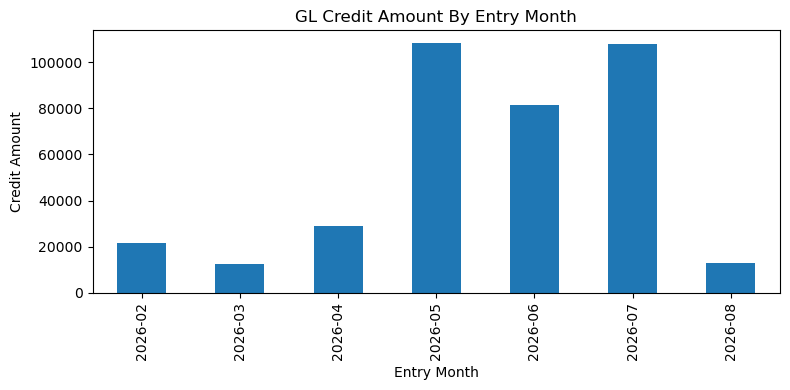

In [5]:
if not gl_account_summary_clean.empty:
    gl_balance_summary = (
        gl_account_summary_clean
        .sort_values("gl_current_balance_abs", ascending=False)
        [[col for col in [
            "gl_account_code",
            "gl_account_description",
            "gl_current_balance",
            "gl_current_balance_abs",
            "gl_entry_rows",
            "gl_total_credit_amount",
            "gl_first_entry_date",
            "gl_last_entry_date"
        ] if col in gl_account_summary_clean.columns]]
    )
    display(gl_balance_summary.head(25))

if not gl_entries_clean.empty and "gl_entry_period_month" in gl_entries_clean.columns:
    gl_monthly_credits = (
        gl_entries_clean
        .groupby("gl_entry_period_month", dropna=False)["gl_credit_amount"]
        .agg(["count", "sum", "mean"])
        .sort_index()
    )
    display(gl_monthly_credits)

    plt.figure(figsize=(8, 4))
    gl_monthly_credits["sum"].plot(kind="bar")
    plt.title("GL Credit Amount By Entry Month")
    plt.xlabel("Entry Month")
    plt.ylabel("Credit Amount")
    plt.tight_layout()
    plt.show()


supplier_reference_match_status
Derived from SupportData.xlsx    73320
Name: count, dtype: int64

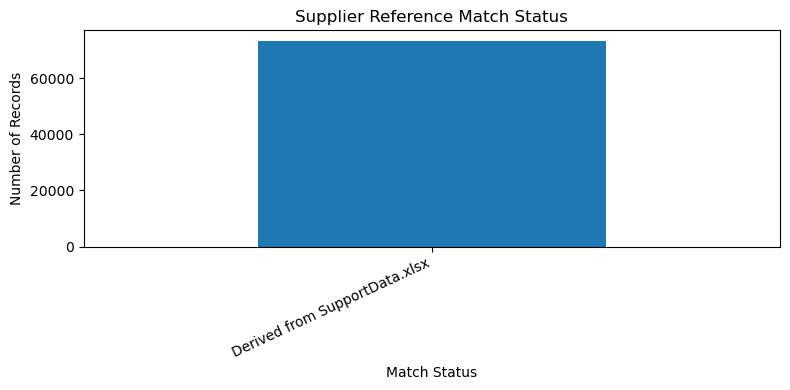

In [6]:
if "supplier_reference_match_status" in df.columns:
    match_summary = df["supplier_reference_match_status"].value_counts(dropna=False)
    display(match_summary)

    plt.figure(figsize=(8, 4))
    match_summary.plot(kind="bar")
    plt.title("Supplier Reference Match Status")
    plt.xlabel("Match Status")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

In [7]:
period_col = None

for candidate in ["customer_period_month", "Date_customer", "claim_date"]:
    if candidate in df.columns:
        period_col = candidate
        break

print("Selected period column:", period_col)

Selected period column: claim_date


,count,sum,mean
analysis_period,,,
2024-07,2201,81246.5269,36.913461
2024-08,2617,102056.3609,38.997463
2024-09,2213,71085.8389,32.121934
2024-10,2779,102396.0504,36.846366
2024-11,2970,74805.9346,25.187183
2024-12,1948,59133.4720,30.355992
2025-01,2358,91869.1743,38.960634
2025-02,2776,82655.1195,29.774899
2025-03,2805,104787.5270,37.357407


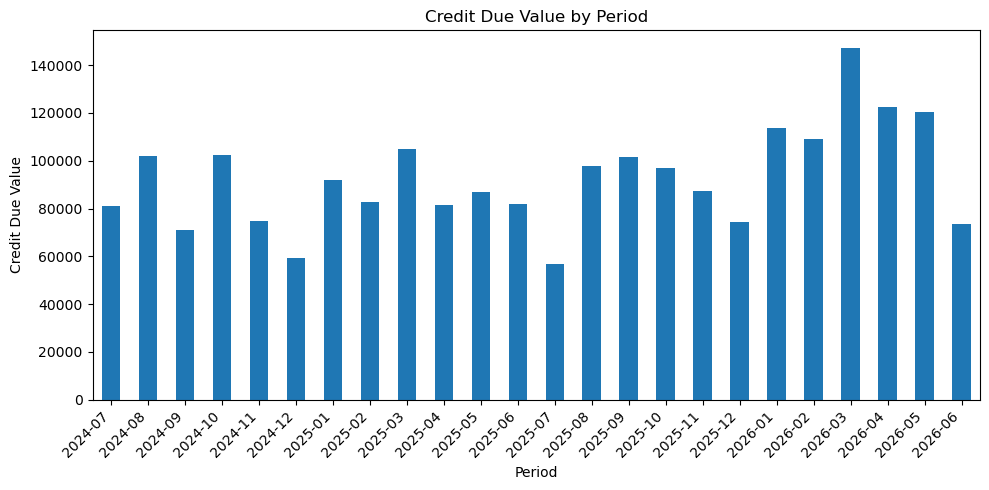

In [8]:
if period_col is not None and "credit_due_value" in df.columns:
    period_df = df.copy()
    
    if np.issubdtype(period_df[period_col].dtype, np.datetime64):
        period_df["analysis_period"] = period_df[period_col].dt.to_period("M").astype(str)
    else:
        period_df["analysis_period"] = period_df[period_col].astype(str)

    claims_by_period = (
        period_df
        .groupby("analysis_period", dropna=False)["credit_due_value"]
        .agg(["count", "sum", "mean"])
        .sort_index()
    )

    display(claims_by_period.tail(24))

    plt.figure(figsize=(10, 5))
    claims_by_period["sum"].tail(24).plot(kind="bar")
    plt.title("Credit Due Value by Period")
    plt.xlabel("Period")
    plt.ylabel("Credit Due Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [9]:
if {"Customer", "Contract_Supplier_Name"}.issubset(df.columns):
    customer_supplier_summary = (
        df.groupby(["Customer", "Contract_Supplier_Name"], dropna=False)["credit_due_value"]
        .agg(["count", "sum", "mean"])
        .sort_values("sum", ascending=False)
        .head(20)
    )
    print("Top 20 customer-supplier pairs by 2026 credit due value")
    display(customer_supplier_summary)
elif {"Customer", "Contract_Supplier"}.issubset(df.columns):
    customer_supplier_summary = (
        df.groupby(["Customer", "Contract_Supplier"], dropna=False)["credit_due_value"]
        .agg(["count", "sum", "mean"])
        .sort_values("sum", ascending=False)
        .head(20)
    )
    print("Top 20 customer-supplier pairs by 2026 credit due value")
    display(customer_supplier_summary)

group_candidates = [
    "Contract_Supplier_Name",
    "Contract_Supplier",
    "Customer_Name",
    "Customer",
    "Product_ManufacturerProductCode",
    "Product",
    "Product_Category",
    "Contract_Number",
    "Contract_D_ContractNumber"
]

for group_col in group_candidates:
    if group_col in df.columns and "credit_due_value" in df.columns:
        summary = (
            df.groupby(group_col, dropna=False)["credit_due_value"]
            .agg(["count", "sum", "mean"])
            .sort_values("sum", ascending=False)
            .head(20)
        )
        
        print(f"Top 20 by {group_col}")
        display(summary)


Top 20 customer-supplier pairs by 2026 credit due value


,,count,sum,mean
Customer,Contract_Supplier_Name,,,
KAN100GB,Supplier19,129,143582.5496,1113.043020
GEN020,Supplier13,246,137971.6400,560.860325
SCU500,Supplier13,153,118841.6800,776.743007
GEN020,Supplier18,3204,85103.0161,26.561491
CAR051,Supplier21,174,82420.0000,473.678161
ELI490,Supplier13,102,77076.5000,755.651961
NIC100,Supplier13,424,71422.3300,168.448892
GEN020,Supplier4,113,62552.9300,553.565752
IRW100GB,Supplier19,90,56843.3193,631.592437


Top 20 by Contract_Supplier_Name


,count,sum,mean
Contract_Supplier_Name,,,
Supplier13,3192,1.006174e+06,315.217534
Supplier4,990,3.162448e+05,319.439152
Supplier19,1345,3.050484e+05,226.801801
Supplier1,48112,2.632074e+05,5.470723
Supplier18,6079,1.910249e+05,31.423742
Supplier21,509,1.826870e+05,358.913556
Supplier7,2459,4.357197e+04,17.719386
Supplier18GB,83,4.238224e+04,510.629382
Supplier20,1392,3.656412e+04,26.267327


Top 20 by Customer_Name


...

,count,sum,mean
Product_Category,,,
IDEALB2,1516,653044.2400,430.767968
IDEALB3,1460,303890.5700,208.144226
WORC1A,628,234024.5200,372.650510
PRSCU,47080,220329.1819,4.679889
STEL4,200,174491.8051,872.459025
VAILDB,231,145137.0000,628.298701
VN,2855,100033.0978,35.037863
WORC1,356,81620.2400,229.270337
MY10,1629,62997.7715,38.672665


Top 20 by Contract_Number


,count,sum,mean
Contract_Number,,,
843.0,1129,249628.6400,221.105970
1555.0,129,143582.5496,1113.043020
1871.0,473,122101.8200,258.143383
496.0,152,88855.6400,584.576579
163.0,162,82170.0000,507.222222
1273.0,2678,76200.0192,28.454077
1848.0,112,62700.0000,559.821429
715.0,90,56843.3193,631.592437
431.0,27,53542.6200,1983.060000


Top 20 by Contract_D_ContractNumber


,count,sum,mean
Contract_D_ContractNumber,,,
6114466,1401,328377.6500,234.388044
117028080,722,162787.0700,225.466856
6147690,129,143582.5496,1113.043020
P-117426/249844,166,95560.0000,575.662651
6141780,155,90533.9600,584.090065
61247,3204,85103.0161,26.561491
6141779,40,65276.3900,1631.909750
117024584,112,62700.0000,559.821429
6137511,338,59933.9400,177.319349


C:\Users\cathalhe\AppData\Local\Temp\ipykernel_33952\2084578354.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ageing_band", dropna=False)["credit_due_value"]


,count,sum,mean
ageing_band,,,
0-30,0,0.000000e+00,NaN
31-60,0,0.000000e+00,NaN
61-90,609,1.729071e+04,28.391973
91-180,9353,3.923959e+05,41.954017
181-365,18988,6.019536e+05,31.701792
365+,44370,1.496065e+06,33.717943


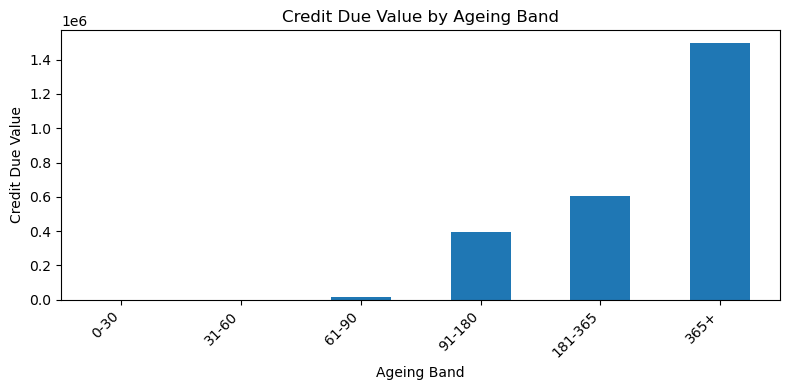

In [10]:
if "ageing_band" in df.columns and "credit_due_value" in df.columns:
    ageing_summary = (
        df.groupby("ageing_band", dropna=False)["credit_due_value"]
        .agg(["count", "sum", "mean"])
    )

    display(ageing_summary)

    plt.figure(figsize=(8, 4))
    ageing_summary["sum"].plot(kind="bar")
    plt.title("Credit Due Value by Ageing Band")
    plt.xlabel("Ageing Band")
    plt.ylabel("Credit Due Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

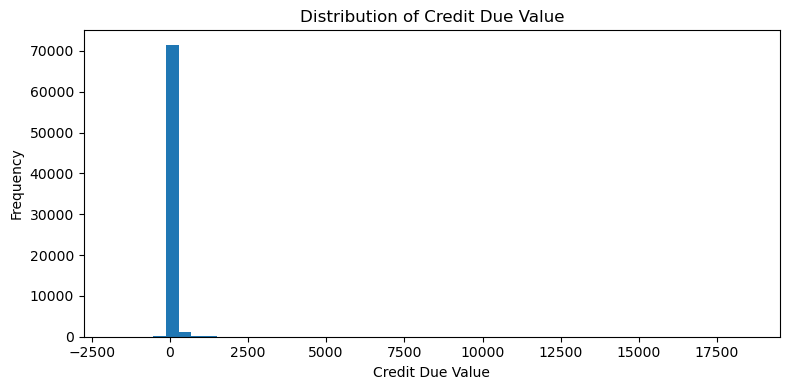

In [11]:
if "credit_due_value" in df.columns:
    plt.figure(figsize=(8, 4))
    df["credit_due_value"].dropna().plot(kind="hist", bins=50)
    plt.title("Distribution of Credit Due Value")
    plt.xlabel("Credit Due Value")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [12]:
if "supplier_reference_match_status" in df.columns and "credit_due_value" in df.columns:
    status_value_summary = (
        df.groupby("supplier_reference_match_status", dropna=False)["credit_due_value"]
        .agg(["count", "sum", "mean"])
        .sort_values("sum", ascending=False)
    )

    display(status_value_summary)

,count,sum,mean
supplier_reference_match_status,,,
Derived from SupportData.xlsx,73320,2.507705e+06,34.202201


In [13]:
review_cols = [
    "requires_review",
    "high_value_review",
    "aged_review"
]

existing_review_cols = [col for col in review_cols if col in df.columns]

if existing_review_cols:
    review_summary = df[existing_review_cols].sum().to_frame("record_count")
    display(review_summary)

,record_count
requires_review,71444


In [14]:
priority_cols = [
    "credit_due_value",
    "days_since_claim",
    "supplier_reference_match_status",
    "requires_review",
    "high_value_review",
    "aged_review",
    "Customer",
    "Customer_Name",
    "Product",
    "Product_ManufacturerProductCode",
    "Contract_Number",
    "Contract_D_ContractNumber",
    "Contract_Supplier_Name",
    "Status"
]

available_priority_cols = [col for col in priority_cols if col in df.columns]

priority_review = df[available_priority_cols].copy()

if "credit_due_value" in priority_review.columns:
    priority_review = priority_review.sort_values("credit_due_value", ascending=False)

display(priority_review.head(10))

,credit_due_value,supplier_reference_match_status,requires_review,Customer,Customer_Name,Product,Product_ManufacturerProductCode,Contract_Number,Contract_D_ContractNumber,Contract_Supplier_Name,Status
68087,18500.0000,Derived from SupportData.xlsx,True,ELL575,W E Elliott & Son Limited,WO30CGR4000NG,7733600373,1900.0,117023463,Supplier4,Claimed
43172,9250.0000,Derived from SupportData.xlsx,True,ELL575,W E Elliott & Son Limited,WO30CGR4000NG,7733600373,1900.0,117023463,Supplier4,Claimed
2058,5940.0000,Derived from SupportData.xlsx,True,CMK020,C M K Mechanical Services Ltd.,IDLOGIC35V2,228309,1091.0,6137506,Supplier13,Claimed
70811,5260.0000,Derived from SupportData.xlsx,True,SDP050,Sd Plumbing & Heating Contracts Ltd.,VAECOSUS28,0010019981,314.0,P-115560/234384,Supplier21,Claimed
32753,5150.0000,Derived from SupportData.xlsx,True,DAV190,Steven Davis T/A Plumbing & Heating,VAECOSUS34,0010019982,164.0,P-117426/249844,Supplier21,Claimed
35346,5150.0000,Derived from SupportData.xlsx,True,DAV190,Steven Davis T/A Plumbing & Heating,VAECOSUS34,0010019982,164.0,P-117426/249844,Supplier21,Claimed
56866,4810.0000,Derived from SupportData.xlsx,True,ELL575,W E Elliott & Son Limited,WO30CGR4000NG,7733600373,1900.0,117023463,Supplier4,Claimed
26173,4800.5298,Derived from SupportData.xlsx,True,KAN100GB,Kane Group Building Services Ltd.,STEL7462212,7462212,1555.0,6147690,Supplier19,Claimed
28195,4281.0593,Derived from SupportData.xlsx,True,SHA900GB,Sharpe Mechanical & Electrical Services Limite...,PE5A2070,5A2070,164.0,039-C-0734,Supplier1,Claimed
32651,3969.3600,Derived from SupportData.xlsx,True,ZZZ284,Gas Care Heating Services Ltd T/A Boiler Genie,IDLOGIC30PLUSV2,228330,885.0,6114466,Supplier13,Claimed


In [15]:
supplier_col = None
for candidate in ["Contract_Supplier_Name", "Contract_Supplier", "contract.supplier.name"]:
    if candidate in df.columns:
        supplier_col = candidate
        break

supplier_performance_summary = pd.DataFrame()

if supplier_col is not None:
    agg_map = {}
    if "claim_line_id" in df.columns:
        agg_map["claim_count"] = ("claim_line_id", "count")
    if "credit_due_value" in df.columns:
        agg_map["credit_due_value"] = ("credit_due_value", "sum")
        agg_map["average_claim_value"] = ("credit_due_value", "mean")
    if "credit_received_value" in df.columns:
        agg_map["confirmed_credit_received"] = ("credit_received_value", "sum")
    if "outstanding_credit_value" in df.columns:
        agg_map["outstanding_credit_value"] = ("outstanding_credit_value", "sum")
    if "requires_review" in df.columns:
        agg_map["review_lines"] = ("requires_review", "sum")
    if "supplier_match_found" in df.columns:
        agg_map["supplier_reference_match_rate"] = ("supplier_match_found", "mean")
    if "days_outstanding" in df.columns:
        agg_map["average_days_outstanding"] = ("days_outstanding", "mean")
    elif "days_since_claim" in df.columns:
        agg_map["average_days_outstanding"] = ("days_since_claim", "mean")

    supplier_performance_summary = (
        df.groupby(supplier_col, dropna=False)
        .agg(**agg_map)
        .reset_index()
        .rename(columns={supplier_col: "supplier"})
    )

    if {"confirmed_credit_received", "credit_due_value"}.issubset(supplier_performance_summary.columns):
        supplier_performance_summary["confirmed_recovery_rate"] = np.where(
            supplier_performance_summary["credit_due_value"].gt(0),
            supplier_performance_summary["confirmed_credit_received"] / supplier_performance_summary["credit_due_value"],
            np.nan
        )

    if {"review_lines", "claim_count"}.issubset(supplier_performance_summary.columns):
        supplier_performance_summary["review_rate"] = np.where(
            supplier_performance_summary["claim_count"].gt(0),
            supplier_performance_summary["review_lines"] / supplier_performance_summary["claim_count"],
            np.nan
        )

    sort_col = "outstanding_credit_value" if "outstanding_credit_value" in supplier_performance_summary.columns else "credit_due_value"
    supplier_performance_summary = supplier_performance_summary.sort_values(sort_col, ascending=False)
    display(supplier_performance_summary.head(10))
else:
    print("No supplier column found for supplier performance summary.")


,supplier,claim_count,credit_due_value,average_claim_value,confirmed_credit_received,outstanding_credit_value,review_lines,average_days_outstanding,confirmed_recovery_rate,review_rate
4,Supplier13,3192,1.006174e+06,315.217534,0.0,1.006174e+06,3129,478.758145,0.0,0.980263
18,Supplier4,990,3.162448e+05,319.439152,0.0,3.162448e+05,964,490.783838,0.0,0.973737
11,Supplier19,1345,3.050484e+05,226.801801,0.0,3.050484e+05,1326,423.691450,0.0,0.985874
0,Supplier1,48112,2.632074e+05,5.470723,0.0,2.632074e+05,46933,484.828047,0.0,0.975495
9,Supplier18,6079,1.910249e+05,31.423742,0.0,1.910249e+05,5971,485.132752,0.0,0.982234
13,Supplier21,509,1.826870e+05,358.913556,0.0,1.826870e+05,496,471.412574,0.0,0.974460
21,Supplier7,2459,4.357197e+04,17.719386,0.0,4.357197e+04,2381,486.671004,0.0,0.968280
10,Supplier18GB,83,4.238224e+04,510.629382,0.0,4.238224e+04,83,746.927711,0.0,1.000000
12,Supplier20,1392,3.656412e+04,26.267327,0.0,3.656412e+04,1322,505.627874,0.0,0.949713
5,Supplier14,3138,2.524243e+04,8.044115,0.0,2.524243e+04,3034,381.191523,0.0,0.966858


C:\Users\cathalhe\AppData\Local\Temp\ipykernel_33952\920574696.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(risk_group_cols, dropna=False)


,Contract_Supplier_Name,ageing_band,credit_recovery_status,claim_count,credit_due_value,outstanding_credit_value,margin_at_risk,average_margin_at_risk
59,Supplier13,365+,Outstanding,1859,586418.7500,586418.7500,586418.7500,315.448494
57,Supplier13,181-365,Outstanding,850,280821.0400,280821.0400,280821.0400,330.377694
143,Supplier19,365+,Outstanding,664,183883.4633,183883.4633,183883.4633,276.932927
11,Supplier1,365+,Outstanding,29670,183327.6623,183327.6623,183327.6623,6.178890
227,Supplier4,365+,Outstanding,595,182536.7500,182536.7500,182536.7500,306.784454
55,Supplier13,91-180,Outstanding,395,150933.0600,150933.0600,150933.0600,382.109013
119,Supplier18,365+,Outstanding,3792,120667.7161,120667.7161,120667.7161,31.821655
167,Supplier21,365+,Outstanding,291,113078.0000,113078.0000,113078.0000,388.584192
225,Supplier4,181-365,Outstanding,245,79669.7300,79669.7300,79669.7300,325.182571
139,Supplier19,91-180,Outstanding,298,77889.8035,77889.8035,77889.8035,261.375180


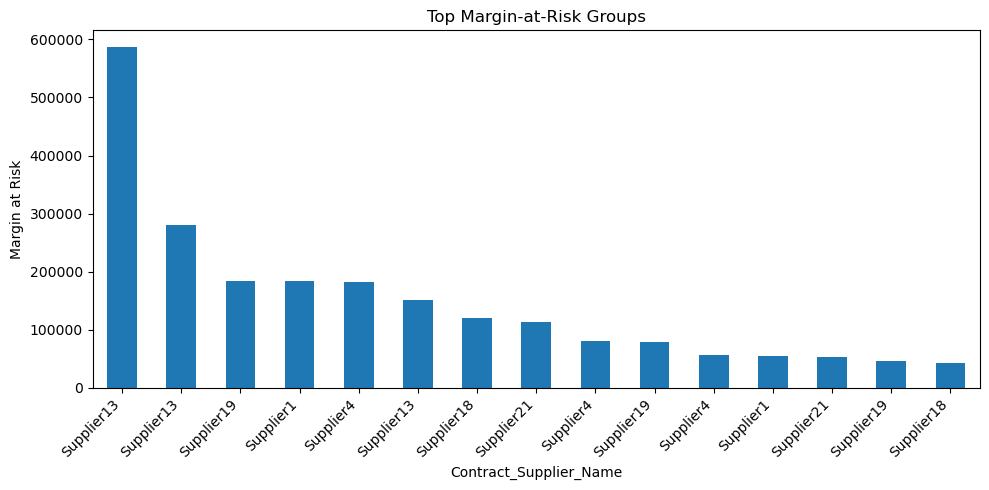

In [16]:
margin_at_risk_analysis = pd.DataFrame()

if "credit_due_value" in df.columns:
    margin_df = df.copy()

    if "margin_at_risk_from_unpaid_credit" not in margin_df.columns:
        margin_df["margin_at_risk_from_unpaid_credit"] = margin_df.get("outstanding_credit_value", margin_df["credit_due_value"])

    risk_group_cols = [col for col in [supplier_col, "ageing_band", "credit_recovery_status"] if col is not None and col in margin_df.columns]

    if risk_group_cols:
        margin_at_risk_analysis = (
            margin_df
            .groupby(risk_group_cols, dropna=False)
            .agg(
                claim_count=("claim_line_id", "count") if "claim_line_id" in margin_df.columns else ("credit_due_value", "count"),
                credit_due_value=("credit_due_value", "sum"),
                outstanding_credit_value=("outstanding_credit_value", "sum") if "outstanding_credit_value" in margin_df.columns else ("credit_due_value", "sum"),
                margin_at_risk=("margin_at_risk_from_unpaid_credit", "sum"),
                average_margin_at_risk=("margin_at_risk_from_unpaid_credit", "mean")
            )
            .reset_index()
            .sort_values("margin_at_risk", ascending=False)
        )
        display(margin_at_risk_analysis.head(10))

        plt.figure(figsize=(10, 5))
        margin_at_risk_analysis.head(15).set_index(risk_group_cols[0])["margin_at_risk"].plot(kind="bar")
        plt.title("Top Margin-at-Risk Groups")
        plt.xlabel(risk_group_cols[0])
        plt.ylabel("Margin at Risk")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No grouping columns found for margin-at-risk analysis.")


## GL & Support Owed Comparison Graphs

Original reconciliation is kept first, then the Supplier1 `PRSCU` rebate adjustment is shown separately because that category is recorded as support but paid as a rebate rather than through the normal claimback route.


In [17]:
import re

SUPPORT_FILE = Path("SupportData.xlsx")
GL_ACCOUNT_FILE = Path("GLAccountData.xlsx")
GL_ENTRY_FILE = Path("GLEntryData.xlsx")
REPORT_YEAR = 2026
REPORT_START_DATE = pd.Timestamp(f"{REPORT_YEAR}-01-01")
SUPPORT_END_DATE = pd.Timestamp("2026-06-01")
LEDGER_END_DATE = pd.Timestamp("2026-07-01")
REPORT_EXCLUDED_SUPPLIER_CODES = {"E005GB", "E059"}
REBATE_SUPPLIER_CODE = "U106"
REBATE_PRODUCT_CATEGORY = "PRSCU"


def report_supplier_group_code(code):
    if pd.isna(code):
        return ""
    code = str(code).strip()
    if code in {"L810", "L812"}:
        return "L810/L812"
    if code in {"E907", "E907GB"}:
        return "E907/E907GB"
    return code


def report_supplier_group_name(code, name):
    group = report_supplier_group_code(code)
    if group == "L810/L812":
        return "Supplier14"
    if group == "E907/E907GB":
        return "Supplier21"
    return "" if pd.isna(name) else str(name).strip()


def report_extract_supplier_code(description):
    text = "" if pd.isna(description) else str(description).upper()
    matches = re.findall(r"\b[A-Z]\d{3}(?:GB)?\b", text)
    return report_supplier_group_code(matches[-1]) if matches else ""


def report_money_axis(axis):
    axis.xaxis.set_major_formatter(lambda x, pos: f"GBP {x/1000:,.0f}k")


def report_showfig():
    plt.tight_layout()
    plt.show()


def load_report_support():
    usecols = [
        "Date", "SourceTransactionType", "Contract_Supplier_Code", "Contract_Supplier_Name",
        "Contract_D_ContractNumber", "Customer", "Product", "Product_Category", "UnitClaimAmount",
        "SalesDeliveryNoteLine_Quantity", "SalesInvoiceLine_Quantity",
        "SalesDeliveryNote_NetAmountLessDiscountBase",
    ]
    report_support = clean_columns(read_cleaned_dataset(support_cleaned_file))
    report_support = report_support[[col for col in usecols if col in report_support.columns]]
    report_support["Date"] = pd.to_datetime(report_support["Date"], errors="coerce")
    report_support = report_support[
        report_support["Date"].ge(REPORT_START_DATE)
        & report_support["Date"].lt(SUPPORT_END_DATE)
        & report_support["SourceTransactionType"].eq("SL/Del")
        & ~report_support["Contract_Supplier_Code"].isin(REPORT_EXCLUDED_SUPPLIER_CODES)
    ].copy()
    report_support["SupplierCode"] = report_support["Contract_Supplier_Code"].map(report_supplier_group_code)
    report_support["SupplierName"] = [
        report_supplier_group_name(c, n)
        for c, n in zip(report_support["Contract_Supplier_Code"], report_support["Contract_Supplier_Name"])
    ]
    report_support["Quantity"] = pd.to_numeric(report_support["SalesDeliveryNoteLine_Quantity"], errors="coerce")
    report_support["Quantity"] = report_support["Quantity"].fillna(
        pd.to_numeric(report_support["SalesInvoiceLine_Quantity"], errors="coerce")
    ).fillna(0)
    report_support["UnitClaimAmount"] = pd.to_numeric(report_support["UnitClaimAmount"], errors="coerce").fillna(0)
    report_support["TotalSupportOwed"] = report_support["UnitClaimAmount"] * report_support["Quantity"]
    report_support["Month"] = report_support["Date"].dt.to_period("M").dt.to_timestamp()
    return report_support


def load_report_ledger():
    accounts = clean_columns(read_cleaned_dataset(gl_accounts_cleaned_file)).rename(columns={
        "Code": "GLAccountCode",
        "Description": "GLAccountDescription",
        "gl_account_code": "GLAccountCode",
        "gl_account_description": "GLAccountDescription",
    })
    entries = clean_columns(read_cleaned_dataset(gl_entries_cleaned_file)).rename(columns={
        "GL_Account_Code": "GLAccountCode",
        "GL Account Code": "GLAccountCode",
        "Entry_Line_Date": "LedgerDate",
        "Entry Line Date": "LedgerDate",
        "Credit_Amount": "CreditAmount",
        "Credit Amount": "CreditAmount",
        "Running_Balance": "RunningBalance",
        "Running Balance": "RunningBalance",
        "Total_Balance": "TotalBalance",
        "Total Balance": "TotalBalance",
    })
    accounts = accounts.loc[:, ~accounts.columns.duplicated()].copy()
    entries = entries.loc[:, ~entries.columns.duplicated()].copy()
    accounts["SupplierCode"] = accounts["GLAccountDescription"].map(report_extract_supplier_code)
    entries["LedgerDate"] = pd.to_datetime(entries["LedgerDate"], errors="coerce")
    entries["CreditAmount"] = pd.to_numeric(entries["CreditAmount"], errors="coerce").fillna(0)
    report_ledger = entries.merge(
        accounts[["GLAccountCode", "GLAccountDescription", "SupplierCode"]],
        on="GLAccountCode",
        how="left",
    )
    if "Description" in report_ledger.columns:
        missing = report_ledger["SupplierCode"].isna() | report_ledger["SupplierCode"].eq("")
        report_ledger.loc[missing, "SupplierCode"] = report_ledger.loc[missing, "Description"].map(report_extract_supplier_code)
    report_ledger = report_ledger[
        report_ledger["LedgerDate"].ge(REPORT_START_DATE)
        & report_ledger["LedgerDate"].lt(LEDGER_END_DATE)
    ].copy()
    report_ledger["Month"] = report_ledger["LedgerDate"].dt.to_period("M").dt.to_timestamp()
    return report_ledger


def build_report_summary(report_support, report_ledger):
    names = report_support.groupby("SupplierCode", as_index=False).agg(
        SupplierName=("SupplierName", "first"),
        LinkedSupplierCodes=("Contract_Supplier_Code", lambda s: ", ".join(sorted(set(str(x) for x in s.dropna())))),
    )
    owed = report_support.groupby("SupplierCode", as_index=False).agg(
        SupportLines=("Date", "size"),
        ContractCount=("Contract_D_ContractNumber", "nunique"),
        CustomerCount=("Customer", "nunique"),
        ProductCount=("Product", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        TotalSupportOwed=("TotalSupportOwed", "sum"),
        FirstSupportDate=("Date", "min"),
        LastSupportDate=("Date", "max"),
    )
    paid = report_ledger[report_ledger["SupplierCode"].ne("")].groupby("SupplierCode", as_index=False).agg(
        LedgerPaid=("CreditAmount", "sum"),
        LedgerLines=("LedgerDate", "size"),
        LatestLedgerDate=("LedgerDate", "max"),
    )
    report_summary = names.merge(owed, on="SupplierCode", how="left").merge(paid, on="SupplierCode", how="left")
    report_summary["LedgerPaid"] = report_summary["LedgerPaid"].fillna(0)
    report_summary["Outstanding"] = report_summary["TotalSupportOwed"] - report_summary["LedgerPaid"]
    report_summary["PaidPct"] = report_summary["LedgerPaid"].div(report_summary["TotalSupportOwed"]).where(report_summary["TotalSupportOwed"].ne(0), 0)
    return report_summary.sort_values("Outstanding", ascending=False)


def build_report_rebate_prscu_adjustment(report_support, report_summary):
    mask = (
        report_support["SupplierCode"].eq(REBATE_SUPPLIER_CODE)
        & report_support["Product_Category"].astype("string").str.upper().eq(REBATE_PRODUCT_CATEGORY)
    )
    prscu = report_support.loc[mask].copy()
    rebate_supplier = report_summary.loc[report_summary["SupplierCode"].eq(REBATE_SUPPLIER_CODE)]
    if rebate_supplier.empty:
        return pd.DataFrame(), report_summary.copy()

    row = rebate_supplier.iloc[0]
    removed_value = prscu["TotalSupportOwed"].sum()
    adjusted_summary = report_summary.copy()
    adjusted_index = adjusted_summary["SupplierCode"].eq(REBATE_SUPPLIER_CODE)
    adjusted_summary.loc[adjusted_index, "SupportLines"] = adjusted_summary.loc[adjusted_index, "SupportLines"] - len(prscu)
    adjusted_summary.loc[adjusted_index, "TotalQuantity"] = adjusted_summary.loc[adjusted_index, "TotalQuantity"] - prscu["Quantity"].sum()
    adjusted_summary.loc[adjusted_index, "TotalSupportOwed"] = adjusted_summary.loc[adjusted_index, "TotalSupportOwed"] - removed_value
    adjusted_summary.loc[adjusted_index, "Outstanding"] = adjusted_summary.loc[adjusted_index, "TotalSupportOwed"] - adjusted_summary.loc[adjusted_index, "LedgerPaid"]
    adjusted_summary.loc[adjusted_index, "PaidPct"] = (
        adjusted_summary.loc[adjusted_index, "LedgerPaid"]
        .div(adjusted_summary.loc[adjusted_index, "TotalSupportOwed"])
        .where(adjusted_summary.loc[adjusted_index, "TotalSupportOwed"].ne(0), 0)
    )
    adjusted_summary = adjusted_summary.sort_values("Outstanding", ascending=False)
    adjusted_row = adjusted_summary.loc[adjusted_summary["SupplierCode"].eq(REBATE_SUPPLIER_CODE)].iloc[0]
    adjustment = pd.DataFrame([{
        "SupplierCode": REBATE_SUPPLIER_CODE,
        "SupplierName": row["SupplierName"],
        "AdjustmentReason": "Product category PRSCU is recorded as claim support but paid through rebate, so it is shown separately from Supplier1 claimback outstanding.",
        "ProductCategoryRemoved": REBATE_PRODUCT_CATEGORY,
        "SupportLinesRemoved": len(prscu),
        "ProductsRemoved": prscu["Product"].nunique(),
        "CustomersRemoved": prscu["Customer"].nunique(),
        "OriginalSupportOwed": row["TotalSupportOwed"],
        "PRSCUSupportOwedRemoved": removed_value,
        "AdjustedSupportOwed": adjusted_row["TotalSupportOwed"],
        "LedgerPaidRetained": row["LedgerPaid"],
        "OriginalOutstanding": row["Outstanding"],
        "AdjustedOutstanding": adjusted_row["Outstanding"],
        "OriginalTotalOutstanding": report_summary["Outstanding"].sum(),
        "AdjustedTotalOutstanding": adjusted_summary["Outstanding"].sum(),
    }])
    return adjustment, adjusted_summary


def build_report_validation(report_support, report_ledger, report_summary, rebate_supplier_adjustment):
    merged_codes = report_support.groupby("SupplierCode")["Contract_Supplier_Code"].nunique()
    rows = [
        {"Check": "Valid 2026 support lines", "Evidence": len(report_support)},
        {"Check": "Support date range", "Evidence": f"{report_support['Date'].min().date()} to {report_support['Date'].max().date()}"},
        {"Check": "Ledger payment date range", "Evidence": f"{report_ledger['LedgerDate'].min().date()} to {report_ledger['LedgerDate'].max().date()}" if len(report_ledger) else "No ledger payments"},
        {"Check": "Supplier groups", "Evidence": report_summary["SupplierCode"].nunique()},
        {"Check": "Merged supplier groups", "Evidence": ", ".join(sorted(merged_codes[merged_codes.gt(1)].index))},
        {"Check": "Ledger payment lines", "Evidence": len(report_ledger)},
        {"Check": "Total support owed", "Evidence": round(report_summary["TotalSupportOwed"].sum(), 2)},
        {"Check": "Total ledger paid", "Evidence": round(report_summary["LedgerPaid"].sum(), 2)},
        {"Check": "Total outstanding", "Evidence": round(report_summary["Outstanding"].sum(), 2)},
        {"Check": "Arithmetic check owed - paid", "Evidence": round(report_summary["TotalSupportOwed"].sum() - report_summary["LedgerPaid"].sum(), 2)},
        {"Check": "Suppliers with positive outstanding", "Evidence": int(report_summary["Outstanding"].gt(0).sum())},
    ]
    if not rebate_supplier_adjustment.empty:
        adj = rebate_supplier_adjustment.iloc[0]
        rows.extend([
            {"Check": "Supplier1 PRSCU support shown separately", "Evidence": round(adj["PRSCUSupportOwedRemoved"], 2)},
            {"Check": "Adjusted total outstanding excluding Supplier1 PRSCU", "Evidence": round(adj["AdjustedTotalOutstanding"], 2)},
        ])
    return pd.DataFrame(rows)


def build_report_monthly(report_support, report_ledger):
    support_with_adjustment = report_support.copy()
    support_with_adjustment["Supplier1PRSCUAdjustment"] = np.where(
        support_with_adjustment["SupplierCode"].eq(REBATE_SUPPLIER_CODE)
        & support_with_adjustment["Product_Category"].astype("string").str.upper().eq(REBATE_PRODUCT_CATEGORY),
        support_with_adjustment["TotalSupportOwed"],
        0,
    )
    support_month = support_with_adjustment.groupby("Month", as_index=False).agg(
        TotalSupportOwed=("TotalSupportOwed", "sum"),
        Supplier1PRSCUAdjustment=("Supplier1PRSCUAdjustment", "sum"),
    )
    ledger_month = report_ledger.groupby("Month", as_index=False).agg(
        LedgerPaid=("CreditAmount", "sum"),
    )
    report_monthly = support_month.merge(ledger_month, on="Month", how="outer").fillna(0).sort_values("Month")
    report_monthly["AdjustedSupportOwed"] = report_monthly["TotalSupportOwed"] - report_monthly["Supplier1PRSCUAdjustment"]
    report_monthly["OriginalMonthlyMovement"] = report_monthly["TotalSupportOwed"] - report_monthly["LedgerPaid"]
    report_monthly["AdjustedMonthlyMovement"] = report_monthly["AdjustedSupportOwed"] - report_monthly["LedgerPaid"]
    report_monthly["MonthLabel"] = report_monthly["Month"].dt.strftime("%b %Y")
    return report_monthly[[
        "Month", "MonthLabel", "TotalSupportOwed", "Supplier1PRSCUAdjustment",
        "AdjustedSupportOwed", "LedgerPaid", "OriginalMonthlyMovement", "AdjustedMonthlyMovement",
    ]]


report_support = load_report_support()
report_ledger = load_report_ledger()
report_summary = build_report_summary(report_support, report_ledger)
rebate_prscu_adjustment, report_summary_rebate_adjusted = build_report_rebate_prscu_adjustment(report_support, report_summary)
report_validation = build_report_validation(report_support, report_ledger, report_summary, rebate_prscu_adjustment)
report_monthly = build_report_monthly(report_support, report_ledger)
report_monthly_table = (
    report_monthly.assign(Month=report_monthly["Month"].dt.strftime("%b"))
    [["Month", "TotalSupportOwed", "LedgerPaid", "OriginalMonthlyMovement"]]
    .rename(columns={
        "TotalSupportOwed": "Total Support Owed",
        "LedgerPaid": "Ledger Paid",
        "OriginalMonthlyMovement": "Monthly Movement",
    })
)

display(report_validation)
display(
    report_monthly_table.style
    .format({
        "Total Support Owed": "£ {:,.2f}",
        "Ledger Paid": "£ {:,.2f}",
        "Monthly Movement": "£ {:,.2f}",
    })
    .set_caption("Table 2 - Monthly values of support owed vs. support paid.")
)
display(report_monthly.drop(columns=["Month"]).round(2))
display(report_summary.head(10))
display(rebate_prscu_adjustment)
display(report_summary_rebate_adjusted.head(10))



C:\Users\cathalhe\AppData\Local\Temp\ipykernel_33952\538862638.py:25: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


,Check,Evidence
0,Valid 2026 support lines,11848
1,Support date range,2026-01-05 to 2026-05-30
2,Ledger payment date range,2026-02-09 to 2026-06-29
3,Supplier groups,19
4,Merged supplier groups,"E907/E907GB, L810/L812"
5,Ledger payment lines,115
6,Total support owed,537101.58
7,Total ledger paid,246267.6
8,Total outstanding,290833.98
9,Arithmetic check owed - paid,290833.98


,Month,Total Support Owed,Ledger Paid,Monthly Movement
0,Jan,"£ 102,658.79",£ 0.00,"£ 102,658.79"
1,Feb,"£ 98,972.78","£ 21,596.54","£ 77,376.24"
2,Mar,"£ 133,632.25","£ 12,509.06","£ 121,123.19"
3,Apr,"£ 91,130.81","£ 28,926.66","£ 62,204.15"
4,May,"£ 110,706.96","£ 108,502.15","£ 2,204.81"
5,Jun,£ 0.00,"£ 81,549.19","£ -81,549.19"


,MonthLabel,TotalSupportOwed,Supplier1PRSCUAdjustment,AdjustedSupportOwed,LedgerPaid,OriginalMonthlyMovement,AdjustedMonthlyMovement
0,Jan 2026,102658.79,4615.16,98043.63,0.00,102658.79,98043.63
1,Feb 2026,98972.78,6514.93,92457.85,21596.54,77376.24,70861.31
2,Mar 2026,133632.25,7198.30,126433.95,12509.06,121123.19,113924.89
3,Apr 2026,91130.81,6298.42,84832.39,28926.66,62204.15,55905.73
4,May 2026,110706.96,6063.36,104643.59,108502.15,2204.81,-3858.56
5,Jun 2026,0.00,0.00,0.00,81549.19,-81549.19,-81549.19


,SupplierCode,SupplierName,LinkedSupplierCodes,SupportLines,ContractCount,CustomerCount,ProductCount,TotalQuantity,TotalSupportOwed,FirstSupportDate,LastSupportDate,LedgerPaid,LedgerLines,LatestLedgerDate,Outstanding,PaidPct
2,E070,Supplier19,E070,410,11,12,123,1089,105767.424605,2026-01-05,2026-05-29,9124.28,4.0,2026-04-20,96643.144605,0.086267
3,E071,Supplier13,E071,617,28,102,21,1028,229976.830000,2026-01-05,2026-05-29,149850.93,64.0,2026-06-22,80125.900000,0.651591
17,U102,Supplier4,U102,173,6,57,16,219,60509.640000,2026-01-05,2026-05-29,0.00,NaN,NaT,60509.640000,0.000000
18,U106,Supplier1,U106,6645,93,170,190,41953,36316.551481,2026-01-05,2026-05-30,3744.41,1.0,2026-02-23,32572.141481,0.103105
10,E907/E907GB,Supplier21,"E907, E907GB",126,7,51,24,148,33022.000000,2026-01-05,2026-05-29,15486.00,7.0,2026-05-14,17536.000000,0.468960
4,E102,Supplier7,E102,274,2,103,14,584,6618.420000,2026-01-05,2026-05-29,0.00,NaN,NaT,6618.420000,0.000000
9,E631,Supplier16,E631,69,3,3,29,531,1210.531886,2026-01-12,2026-05-22,0.00,NaN,NaT,1210.531886,0.000000
13,L810/L812,Supplier14,"L810, L812",853,0,15,139,30655,6865.409063,2026-01-05,2026-05-29,5811.16,4.0,2026-06-29,1054.249063,0.846440
7,E269A,Supplier17,E269A,55,0,28,4,96,586.000000,2026-02-19,2026-05-26,0.00,NaN,NaT,586.000000,0.000000
16,N023,Supplier22,N023,370,9,8,89,5793,838.750119,2026-01-05,2026-05-28,276.94,3.0,2026-06-22,561.810119,0.330182


,SupplierCode,SupplierName,AdjustmentReason,ProductCategoryRemoved,SupportLinesRemoved,ProductsRemoved,CustomersRemoved,OriginalSupportOwed,PRSCUSupportOwedRemoved,AdjustedSupportOwed,LedgerPaidRetained,OriginalOutstanding,AdjustedOutstanding,OriginalTotalOutstanding,AdjustedTotalOutstanding
0,U106,Supplier1,Product category PRSCU is recorded as claim su...,PRSCU,6538,161,141,36316.551481,30690.167497,5626.383984,3744.41,32572.141481,1881.973984,290833.980259,260143.812762


,SupplierCode,SupplierName,LinkedSupplierCodes,SupportLines,ContractCount,CustomerCount,ProductCount,TotalQuantity,TotalSupportOwed,FirstSupportDate,LastSupportDate,LedgerPaid,LedgerLines,LatestLedgerDate,Outstanding,PaidPct
2,E070,Supplier19,E070,410,11,12,123,1089,105767.424605,2026-01-05,2026-05-29,9124.28,4.0,2026-04-20,96643.144605,0.086267
3,E071,Supplier13,E071,617,28,102,21,1028,229976.830000,2026-01-05,2026-05-29,149850.93,64.0,2026-06-22,80125.900000,0.651591
17,U102,Supplier4,U102,173,6,57,16,219,60509.640000,2026-01-05,2026-05-29,0.00,NaN,NaT,60509.640000,0.000000
10,E907/E907GB,Supplier21,"E907, E907GB",126,7,51,24,148,33022.000000,2026-01-05,2026-05-29,15486.00,7.0,2026-05-14,17536.000000,0.468960
4,E102,Supplier7,E102,274,2,103,14,584,6618.420000,2026-01-05,2026-05-29,0.00,NaN,NaT,6618.420000,0.000000
18,U106,Supplier1,U106,107,93,170,190,575,5626.383984,2026-01-05,2026-05-30,3744.41,1.0,2026-02-23,1881.973984,0.665509
9,E631,Supplier16,E631,69,3,3,29,531,1210.531886,2026-01-12,2026-05-22,0.00,NaN,NaT,1210.531886,0.000000
13,L810/L812,Supplier14,"L810, L812",853,0,15,139,30655,6865.409063,2026-01-05,2026-05-29,5811.16,4.0,2026-06-29,1054.249063,0.846440
7,E269A,Supplier17,E269A,55,0,28,4,96,586.000000,2026-02-19,2026-05-26,0.00,NaN,NaT,586.000000,0.000000
16,N023,Supplier22,N023,370,9,8,89,5793,838.750119,2026-01-05,2026-05-28,276.94,3.0,2026-06-22,561.810119,0.330182


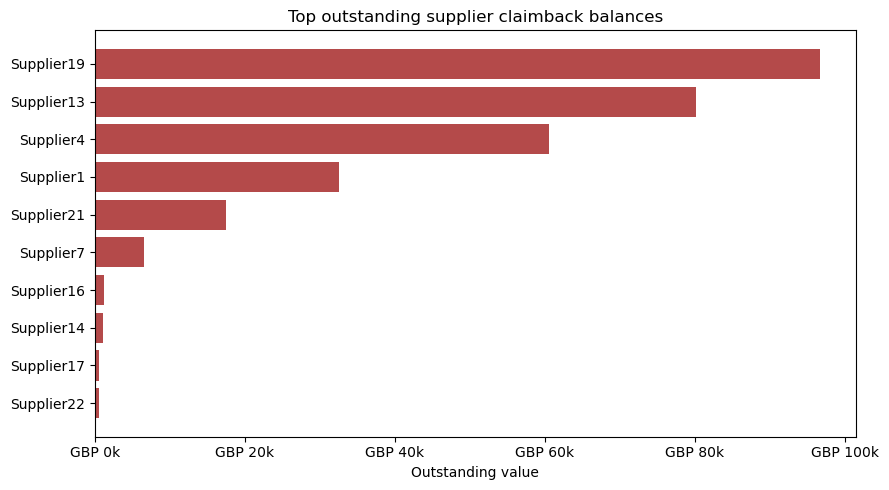

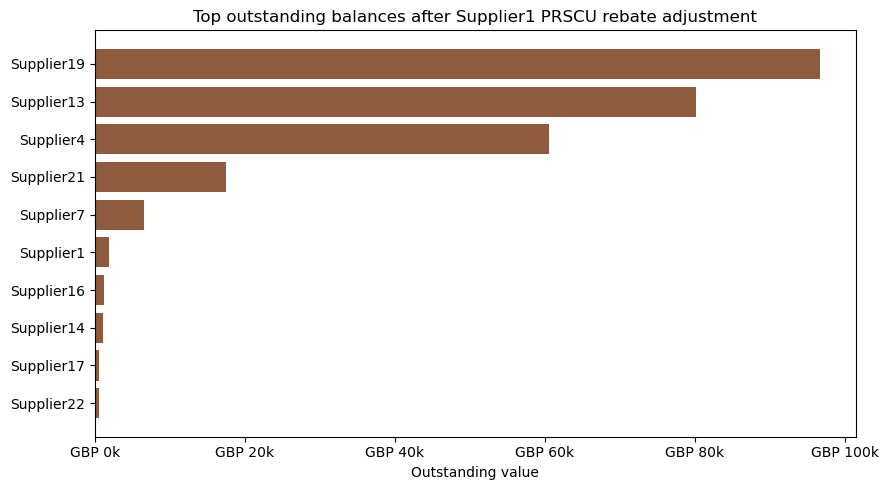

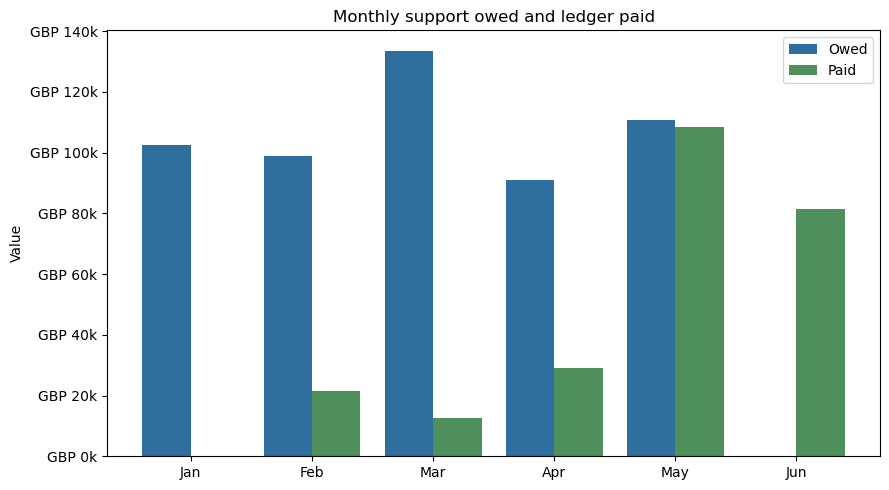

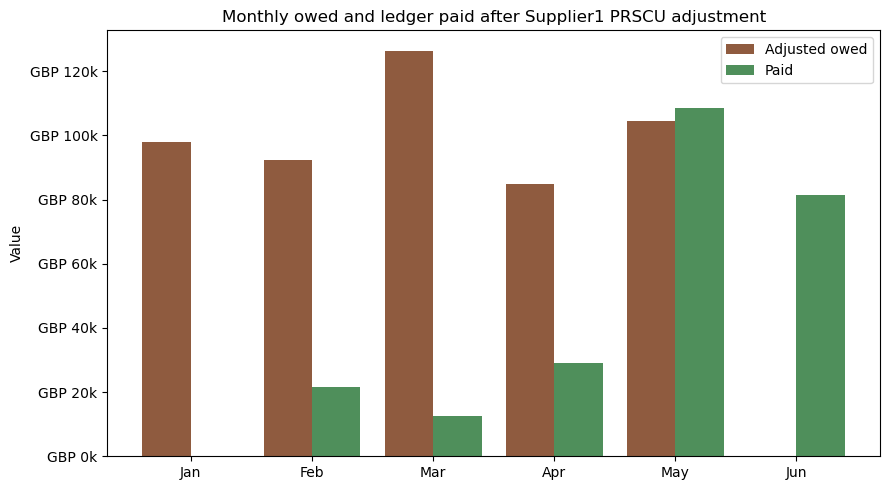

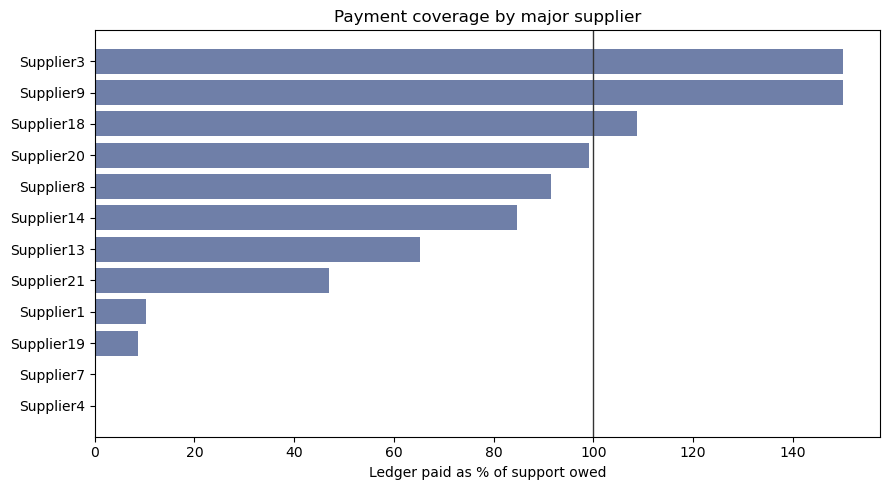

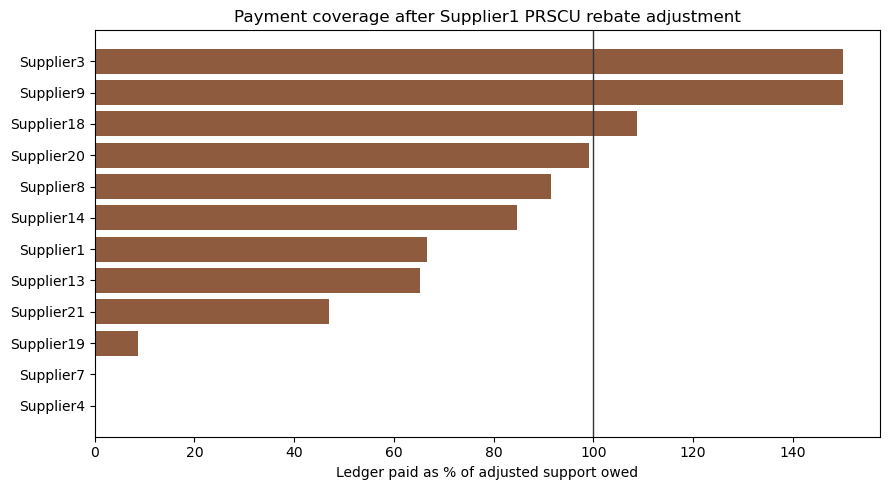

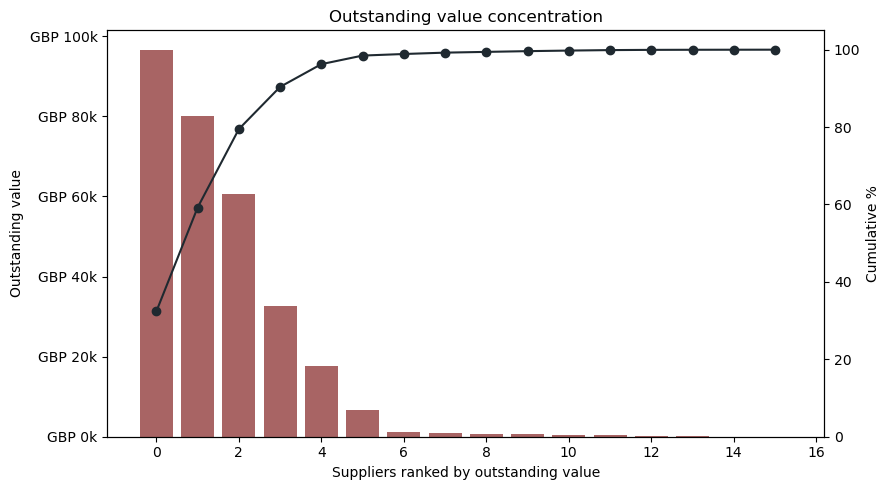

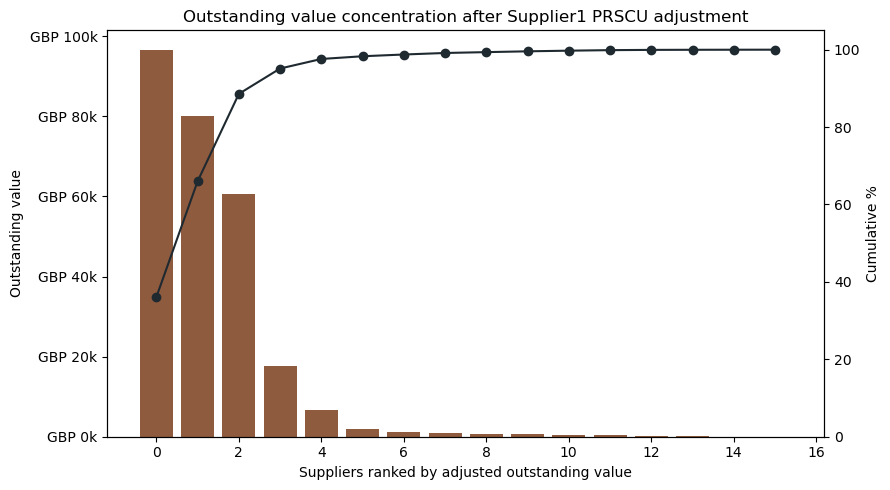

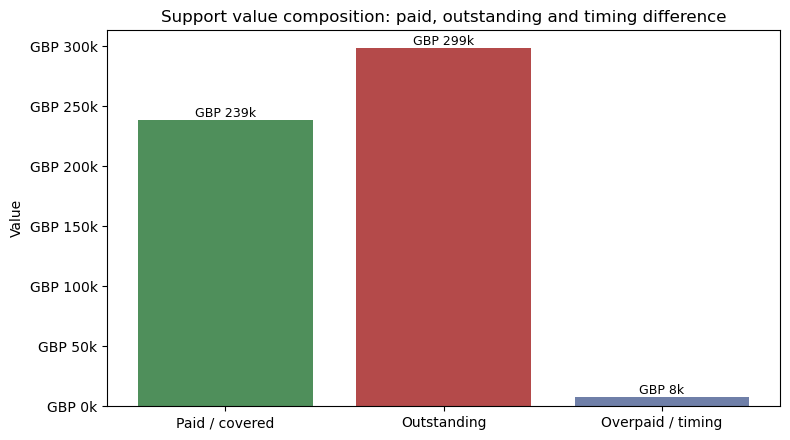

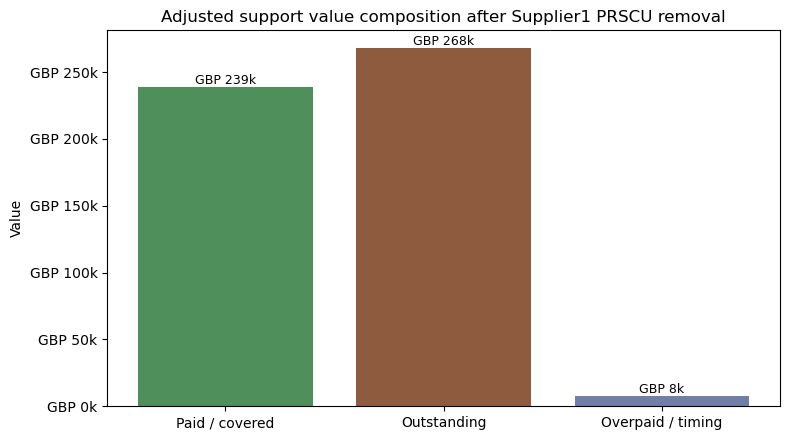

In [18]:
top = report_summary[report_summary["Outstanding"].gt(0)].head(10).sort_values("Outstanding")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["SupplierName"], top["Outstanding"], color="#b44a4a")
ax.set_title("Top outstanding supplier claimback balances")
ax.set_xlabel("Outstanding value")
report_money_axis(ax)
report_showfig()

adjusted_top = report_summary_rebate_adjusted[report_summary_rebate_adjusted["Outstanding"].gt(0)].head(10).sort_values("Outstanding")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(adjusted_top["SupplierName"], adjusted_top["Outstanding"], color="#8f5b3f")
ax.set_title("Top outstanding balances after Supplier1 PRSCU rebate adjustment")
ax.set_xlabel("Outstanding value")
report_money_axis(ax)
report_showfig()

monthly = report_monthly.copy()
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(monthly))
ax.bar([i - 0.2 for i in x], monthly["TotalSupportOwed"], width=0.4, label="Owed", color="#2f6f9f")
ax.bar([i + 0.2 for i in x], monthly["LedgerPaid"], width=0.4, label="Paid", color="#4f8f5b")
ax.set_xticks(list(x), [d.strftime("%b") for d in monthly["Month"]])
ax.set_title("Monthly support owed and ledger paid")
ax.set_ylabel("Value")
ax.legend()
ax.yaxis.set_major_formatter(lambda y, pos: f"GBP {y/1000:,.0f}k")
report_showfig()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - 0.2 for i in x], monthly["AdjustedSupportOwed"], width=0.4, label="Adjusted owed", color="#8f5b3f")
ax.bar([i + 0.2 for i in x], monthly["LedgerPaid"], width=0.4, label="Paid", color="#4f8f5b")
ax.set_xticks(list(x), [d.strftime("%b") for d in monthly["Month"]])
ax.set_title("Monthly owed and ledger paid after Supplier1 PRSCU adjustment")
ax.set_ylabel("Value")
ax.legend()
ax.yaxis.set_major_formatter(lambda y, pos: f"GBP {y/1000:,.0f}k")
report_showfig()

paid_pct = report_summary.sort_values("TotalSupportOwed", ascending=False).head(12).copy().sort_values("PaidPct")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(paid_pct["SupplierName"], paid_pct["PaidPct"].clip(upper=1.5) * 100, color="#6f7fa8")
ax.axvline(100, color="#333333", linewidth=1)
ax.set_title("Payment coverage by major supplier")
ax.set_xlabel("Ledger paid as % of support owed")
report_showfig()

adjusted_paid_pct = report_summary_rebate_adjusted.sort_values("TotalSupportOwed", ascending=False).head(12).copy().sort_values("PaidPct")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(adjusted_paid_pct["SupplierName"], adjusted_paid_pct["PaidPct"].clip(upper=1.5) * 100, color="#8f5b3f")
ax.axvline(100, color="#333333", linewidth=1)
ax.set_title("Payment coverage after Supplier1 PRSCU rebate adjustment")
ax.set_xlabel("Ledger paid as % of adjusted support owed")
report_showfig()

pareto = report_summary[report_summary["Outstanding"].gt(0)].sort_values("Outstanding", ascending=False).copy()
pareto["CumulativePct"] = pareto["Outstanding"].cumsum() / pareto["Outstanding"].sum() * 100
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(range(len(pareto)), pareto["Outstanding"], color="#a86464")
ax1.set_title("Outstanding value concentration")
ax1.set_ylabel("Outstanding value")
ax1.yaxis.set_major_formatter(lambda y, pos: f"GBP {y/1000:,.0f}k")
ax2 = ax1.twinx()
ax2.plot(range(len(pareto)), pareto["CumulativePct"], color="#1f2930", marker="o")
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 105)
ax1.set_xlabel("Suppliers ranked by outstanding value")
report_showfig()

adjusted_pareto = report_summary_rebate_adjusted[report_summary_rebate_adjusted["Outstanding"].gt(0)].sort_values("Outstanding", ascending=False).copy()
adjusted_pareto["CumulativePct"] = adjusted_pareto["Outstanding"].cumsum() / adjusted_pareto["Outstanding"].sum() * 100
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(range(len(adjusted_pareto)), adjusted_pareto["Outstanding"], color="#8f5b3f")
ax1.set_title("Outstanding value concentration after Supplier1 PRSCU adjustment")
ax1.set_ylabel("Outstanding value")
ax1.yaxis.set_major_formatter(lambda y, pos: f"GBP {y/1000:,.0f}k")
ax2 = ax1.twinx()
ax2.plot(range(len(adjusted_pareto)), adjusted_pareto["CumulativePct"], color="#1f2930", marker="o")
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 105)
ax1.set_xlabel("Suppliers ranked by adjusted outstanding value")
report_showfig()

def build_value_composition(summary):
    paid_applied = np.minimum(summary["LedgerPaid"], summary["TotalSupportOwed"]).sum()
    outstanding = (summary["TotalSupportOwed"] - summary["LedgerPaid"]).clip(lower=0).sum()
    overpaid_timing = (summary["LedgerPaid"] - summary["TotalSupportOwed"]).clip(lower=0).sum()
    return pd.DataFrame({
        "Status": ["Paid / covered", "Outstanding", "Overpaid / timing"],
        "Value": [paid_applied, outstanding, overpaid_timing],
    })

status = build_value_composition(report_summary)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(status["Status"], status["Value"], color=["#4f8f5b", "#b44a4a", "#6f7fa8"])
ax.set_title("Support value composition: paid, outstanding and timing difference")
ax.set_ylabel("Value")
ax.yaxis.set_major_formatter(lambda y, pos: f"GBP {y/1000:,.0f}k")
for i, value in enumerate(status["Value"]):
    ax.text(i, value, f"GBP {value/1000:,.0f}k", ha="center", va="bottom", fontsize=9)
report_showfig()

adjusted_status = build_value_composition(report_summary_rebate_adjusted)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(adjusted_status["Status"], adjusted_status["Value"], color=["#4f8f5b", "#8f5b3f", "#6f7fa8"])
ax.set_title("Adjusted support value composition after Supplier1 PRSCU removal")
ax.set_ylabel("Value")
ax.yaxis.set_major_formatter(lambda y, pos: f"GBP {y/1000:,.0f}k")
for i, value in enumerate(adjusted_status["Value"]):
    ax.text(i, value, f"GBP {value/1000:,.0f}k", ha="center", va="bottom", fontsize=9)
report_showfig()

